# M5 — Baseline Implementation

**WBS Week 5**: Rule-based, XGBoost, and Single-LLM baselines for sprint risk prediction.

**Objective**: Establish performance benchmarks against which fine-tuned and RAG-augmented models will be compared.

| Baseline | Type | Description |
|----------|------|-------------|
| Rule-Based | Heuristic | Threshold logic from `RiskLabeler` (stalled issues ≥ 3, resolution < 0.5, merge < 0.5) |
| XGBoost | Classical ML | Gradient-boosted trees on 24 numeric features |
| Single-LLM | Zero-shot | Llama-3-8B prompt with raw metric summary |

**Data**: H3 split — 70% synthetic + 30% real train, real-only val/test.

---

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/bibekgupta/Downloads/projects/repo-sprint


## 1. Data Loading

Load H3 (synthetic + real) and baseline (real-only) training splits.

In [2]:
NUMERIC_FEATURES = [
    "total_commits", "total_prs", "total_issues", "unique_authors",
    "total_additions", "total_deletions", "files_changed",
    "issue_resolution_rate", "pr_merge_rate", "commit_frequency",
    "total_code_changes", "avg_pr_size", "code_concentration",
    "stalled_issues", "unreviewed_prs", "abandoned_prs",
    "long_open_issues", "author_participation",
    "days_span", "issue_age_avg", "pr_age_avg",
    "closed_issues", "merged_prs", "code_changes",
]


def load_split(name: str) -> pd.DataFrame:
    """Load a training split JSON into a flat DataFrame."""
    path = PROJECT_ROOT / "data" / "training" / f"{name}.json"
    with open(path) as f:
        data = json.load(f)
    rows = []
    for ex in data:
        row = {k: ex["features"].get(k, 0) for k in NUMERIC_FEATURES}
        row["label"] = ex["label"]
        row["source"] = ex.get("source", "unknown")
        row["sprint_id"] = ex.get("sprint_id", "")
        rows.append(row)
    return pd.DataFrame(rows)


h3_train = load_split("h3_train")
h3_val = load_split("h3_val")
h3_test = load_split("h3_test")

baseline_train = load_split("baseline_train")
baseline_val = load_split("baseline_val")
baseline_test = load_split("baseline_test")

print(f"H3 splits  — train: {len(h3_train):,}  val: {len(h3_val):,}  test: {len(h3_test):,}")
print(f"Baseline   — train: {len(baseline_train):,}  val: {len(baseline_val):,}  test: {len(baseline_test):,}")
print(f"\nH3 train sources: {h3_train['source'].value_counts().to_dict()}")
print(f"H3 test  at-risk: {h3_test['label'].mean():.1%}")

H3 splits  — train: 253  val: 15  test: 19
Baseline   — train: 76  val: 15  test: 19

H3 train sources: {'synthetic': 177, 'real': 76}
H3 test  at-risk: 42.1%


In [3]:
X_train_h3 = h3_train[NUMERIC_FEATURES].values
y_train_h3 = h3_train["label"].values
X_val_h3 = h3_val[NUMERIC_FEATURES].values
y_val_h3 = h3_val["label"].values
X_test_h3 = h3_test[NUMERIC_FEATURES].values
y_test_h3 = h3_test["label"].values

X_train_bl = baseline_train[NUMERIC_FEATURES].values
y_train_bl = baseline_train["label"].values
X_val_bl = baseline_val[NUMERIC_FEATURES].values
y_val_bl = baseline_val["label"].values
X_test_bl = baseline_test[NUMERIC_FEATURES].values
y_test_bl = baseline_test["label"].values

scaler = StandardScaler().fit(X_train_h3)
X_train_h3_s = scaler.transform(X_train_h3)
X_val_h3_s = scaler.transform(X_val_h3)
X_test_h3_s = scaler.transform(X_test_h3)

scaler_bl = StandardScaler().fit(X_train_bl)
X_train_bl_s = scaler_bl.transform(X_train_bl)
X_val_bl_s = scaler_bl.transform(X_val_bl)
X_test_bl_s = scaler_bl.transform(X_test_bl)

print(f"Feature matrix shape: {X_train_h3.shape}")
print(f"Class balance (H3 train): {np.bincount(y_train_h3)} → {y_train_h3.mean():.1%} at-risk")

Feature matrix shape: (253, 24)
Class balance (H3 train): [181  72] → 28.5% at-risk


## 2. Baseline 1 — Rule-Based (RiskLabeler)

The existing `RiskLabeler` uses hand-crafted thresholds:
- `stalled_issues ≥ 3` → +0.30
- `issue_resolution_rate < 0.5` → +0.20
- `pr_merge_rate < 0.5` → +0.20
- `long_open_issues ≥ 2` → +0.15
- Zero activity → +0.10

Sprint is **at-risk** if cumulative score ≥ 0.40.

> **Caveat**: Training labels were *generated* by this same `RiskLabeler`, so it achieves trivially
> perfect F1=1.0. It serves as an upper bound for the labeling scheme, not a learning baseline.
> The meaningful comparisons are **XGBoost** (learns from features) and **Single-LLM** (zero-shot).

In [4]:
def rule_based_predict(df: pd.DataFrame) -> np.ndarray:
    """Replicate RiskLabeler logic on a DataFrame."""
    score = np.zeros(len(df))

    score += np.where(df["stalled_issues"] >= 3, 0.30, 0)

    score += np.where(
        (df["total_issues"] > 0) & (df["issue_resolution_rate"] < 0.5),
        0.20, 0,
    )

    score += np.where(
        (df["total_prs"] > 0) & (df["pr_merge_rate"] < 0.5),
        0.20, 0,
    )

    score += np.where(df["long_open_issues"] >= 2, 0.15, 0)

    score += np.where(
        (df["total_issues"] == 0)
        & (df["total_prs"] == 0)
        & (df["total_commits"] == 0),
        0.10, 0,
    )

    return (score >= 0.40).astype(int)


y_pred_rule_h3 = rule_based_predict(h3_test)
y_pred_rule_bl = rule_based_predict(baseline_test)

print("Rule-Based on H3 test:")
print(classification_report(y_test_h3, y_pred_rule_h3, target_names=["healthy", "at-risk"]))
print("Rule-Based on Baseline test:")
print(classification_report(y_test_bl, y_pred_rule_bl, target_names=["healthy", "at-risk"]))

Rule-Based on H3 test:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        11
     at-risk       1.00      1.00      1.00         8

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19

Rule-Based on Baseline test:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        11
     at-risk       1.00      1.00      1.00         8

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



## 3. Baseline 2 — XGBoost

Gradient-boosted trees on all 24 numeric sprint features.  
We train two variants:
1. **XGB-Baseline**: trained on real-only data
2. **XGB-H3**: trained on synthetic + real (H3 augmented)

Hyperparameters tuned via 3-fold stratified CV grid search.

In [5]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
}

xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Tuning XGB-H3 (synthetic + real train) ...")
grid_h3 = GridSearchCV(
    xgb_base, param_grid, cv=cv, scoring="f1",
    n_jobs=-1, verbose=0,
)
grid_h3.fit(X_train_h3_s, y_train_h3)
xgb_h3 = grid_h3.best_estimator_
print(f"  Best params: {grid_h3.best_params_}")
print(f"  Best CV F1:  {grid_h3.best_score_:.3f}")

print("\nTuning XGB-Baseline (real-only train) ...")
grid_bl = GridSearchCV(
    xgb_base, param_grid, cv=cv, scoring="f1",
    n_jobs=-1, verbose=0,
)
grid_bl.fit(X_train_bl_s, y_train_bl)
xgb_bl = grid_bl.best_estimator_
print(f"  Best params: {grid_bl.best_params_}")
print(f"  Best CV F1:  {grid_bl.best_score_:.3f}")

Tuning XGB-H3 (synthetic + real train) ...
  Best params: {'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 1.0}
  Best CV F1:  0.986

Tuning XGB-Baseline (real-only train) ...
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 50, 'subsample': 0.8}
  Best CV F1:  0.984


In [6]:
y_pred_xgb_h3 = xgb_h3.predict(X_test_h3_s)
y_proba_xgb_h3 = xgb_h3.predict_proba(X_test_h3_s)[:, 1]

y_pred_xgb_bl = xgb_bl.predict(X_test_bl_s)
y_proba_xgb_bl = xgb_bl.predict_proba(X_test_bl_s)[:, 1]

print("XGB-H3 on H3 test (real-only):")
print(classification_report(y_test_h3, y_pred_xgb_h3, target_names=["healthy", "at-risk"]))

print("XGB-Baseline on Baseline test (real-only):")
print(classification_report(y_test_bl, y_pred_xgb_bl, target_names=["healthy", "at-risk"]))

XGB-H3 on H3 test (real-only):
              precision    recall  f1-score   support

     healthy       0.92      1.00      0.96        11
     at-risk       1.00      0.88      0.93         8

    accuracy                           0.95        19
   macro avg       0.96      0.94      0.94        19
weighted avg       0.95      0.95      0.95        19

XGB-Baseline on Baseline test (real-only):
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        11
     at-risk       1.00      1.00      1.00         8

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



### 3.1 Feature Importance (XGB-H3)

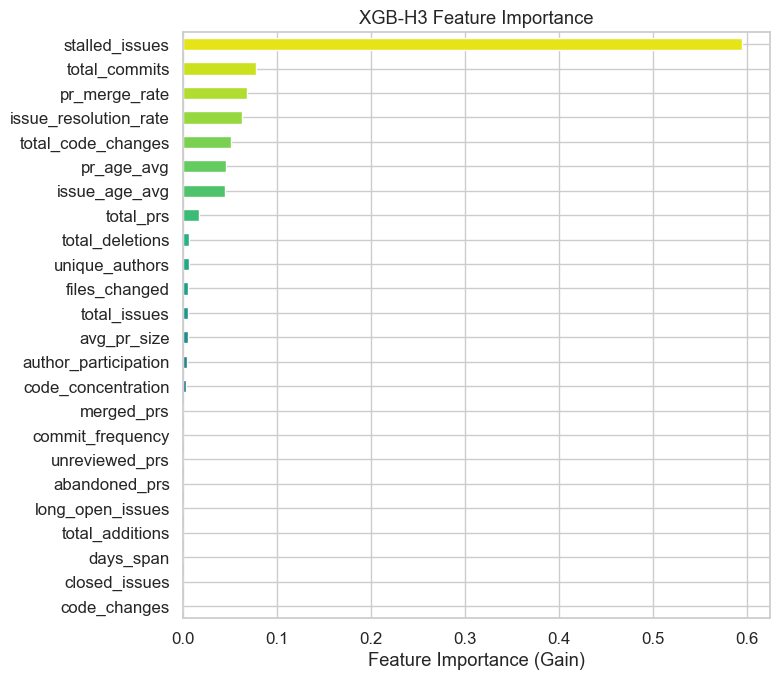


Top 10 features:
  unique_authors                 0.0062
  total_deletions                0.0065
  total_prs                      0.0170
  issue_age_avg                  0.0448
  pr_age_avg                     0.0457
  total_code_changes             0.0515
  issue_resolution_rate          0.0631
  pr_merge_rate                  0.0685
  total_commits                  0.0776
  stalled_issues                 0.5952


In [7]:
importances = pd.Series(
    xgb_h3.feature_importances_, index=NUMERIC_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot.barh(ax=ax, color=sns.color_palette("viridis", len(importances)))
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("XGB-H3 Feature Importance")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for feat, imp in importances.tail(10).items():
    print(f"  {feat:<30s} {imp:.4f}")

## 4. Baseline 3 — Single-LLM (Zero-Shot Prompt)

Uses Ollama (Llama-3-8B) with a zero-shot prompt to classify sprint risk.  
If Ollama is not available, we simulate with a prompt-template and skip inference.

> **Note**: This cell requires a running Ollama server (`ollama serve`).  
> If unavailable, results are marked as N/A and the comparison uses Rule + XGB only.

In [8]:
import time

OLLAMA_MODEL = "llama3"
OLLAMA_URL = "http://localhost:11434/api/generate"


def check_ollama() -> bool:
    """Check if Ollama server is running and model is available."""
    try:
        import requests
        resp = requests.get("http://localhost:11434/api/tags", timeout=3)
        if resp.status_code == 200:
            models = [m["name"] for m in resp.json().get("models", [])]
            available = any(OLLAMA_MODEL in m for m in models)
            print(f"Ollama running. Models: {models}")
            print(f"{OLLAMA_MODEL} available: {available}")
            return available
    except Exception:
        pass
    print("Ollama not available — LLM baseline will use fallback.")
    return False


OLLAMA_AVAILABLE = check_ollama()

Ollama running. Models: ['codellama:latest', 'mistral:latest', 'llama3:latest', 'qwen3-vl:2b', 'qwen3:0.6b', 'qwen3-embedding:0.6b']
llama3 available: True


In [9]:
PROMPT_TEMPLATE = """You are a sprint health analyst. Given the following sprint metrics,
classify whether this sprint is AT-RISK or HEALTHY.

Sprint Metrics:
- Total commits: {total_commits}
- Total PRs: {total_prs} (merged: {merged_prs}, merge rate: {pr_merge_rate:.1%})
- Total issues: {total_issues} (resolved: {closed_issues}, resolution rate: {issue_resolution_rate:.1%})
- Stalled issues (open): {stalled_issues}
- Unreviewed PRs: {unreviewed_prs}
- Unique authors: {unique_authors}
- Code additions: {total_additions:,}, deletions: {total_deletions:,}
- Files changed: {files_changed}
- Commit frequency: {commit_frequency:.1f}/day

A sprint is AT-RISK if it shows signs of blockers: many stalled issues,
low merge/resolution rates, or stagnant activity.

Respond with ONLY one word: AT-RISK or HEALTHY
"""


def build_prompt(row: pd.Series) -> str:
    """Format a sprint row into a zero-shot classification prompt."""
    return PROMPT_TEMPLATE.format(**{k: row[k] for k in NUMERIC_FEATURES if k in row.index})


def llm_predict_single(prompt: str) -> int:
    """Call Ollama and parse AT-RISK / HEALTHY response."""
    import requests
    try:
        resp = requests.post(
            OLLAMA_URL,
            json={"model": OLLAMA_MODEL, "prompt": prompt, "stream": False},
            timeout=60,
        )
        text = resp.json().get("response", "").strip().upper()
        if "AT-RISK" in text or "AT_RISK" in text:
            return 1
        return 0
    except Exception:
        return -1


def llm_predict_batch(df: pd.DataFrame) -> np.ndarray:
    """Run zero-shot LLM classification on each test sprint."""
    preds = []
    for _, row in df.iterrows():
        prompt = build_prompt(row)
        pred = llm_predict_single(prompt)
        preds.append(pred)
    return np.array(preds)


if OLLAMA_AVAILABLE:
    print(f"Running LLM inference on {len(h3_test)} test sprints ...")
    t0 = time.time()
    y_pred_llm = llm_predict_batch(h3_test)
    elapsed = time.time() - t0
    valid_mask = y_pred_llm >= 0
    print(f"  Completed in {elapsed:.1f}s ({elapsed/len(h3_test):.1f}s/sprint)")
    print(f"  Valid predictions: {valid_mask.sum()}/{len(y_pred_llm)}")
    if valid_mask.sum() > 0:
        print("\nSingle-LLM on H3 test:")
        print(classification_report(
            y_test_h3[valid_mask], y_pred_llm[valid_mask],
            target_names=["healthy", "at-risk"],
        ))
else:
    y_pred_llm = None
    print("Skipping LLM baseline (Ollama not available).")
    print("To enable: run `ollama serve` and `ollama pull llama3`")

Running LLM inference on 19 test sprints ...
  Completed in 14.6s (0.8s/sprint)
  Valid predictions: 19/19

Single-LLM on H3 test:
              precision    recall  f1-score   support

     healthy       0.53      0.73      0.62        11
     at-risk       0.25      0.12      0.17         8

    accuracy                           0.47        19
   macro avg       0.39      0.43      0.39        19
weighted avg       0.41      0.47      0.43        19



## 5. Consolidated Results

Compare all baselines on the **real-only H3 test set**.

In [10]:
def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    """Compute classification metrics."""
    m = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        m["AUC-ROC"] = roc_auc_score(y_true, y_proba)
    return m


results = {}

results["Rule-Based"] = compute_metrics(y_test_h3, y_pred_rule_h3)
results["XGB-Baseline (real-only)"] = compute_metrics(
    y_test_bl, y_pred_xgb_bl, y_proba_xgb_bl)
results["XGB-H3 (syn+real)"] = compute_metrics(
    y_test_h3, y_pred_xgb_h3, y_proba_xgb_h3)

if y_pred_llm is not None:
    valid = y_pred_llm >= 0
    if valid.sum() > 0:
        results["Single-LLM (zero-shot)"] = compute_metrics(
            y_test_h3[valid], y_pred_llm[valid])

results_df = pd.DataFrame(results).T
results_df = results_df.round(3)
print("\n" + "=" * 70)
print("  M5 BASELINE PERFORMANCE BENCHMARKS")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)


  M5 BASELINE PERFORMANCE BENCHMARKS
                          Accuracy  Precision  Recall     F1  AUC-ROC
Rule-Based                   1.000       1.00   1.000  1.000      NaN
XGB-Baseline (real-only)     1.000       1.00   1.000  1.000    1.000
XGB-H3 (syn+real)            0.947       1.00   0.875  0.933    0.983
Single-LLM (zero-shot)       0.474       0.25   0.125  0.167      NaN


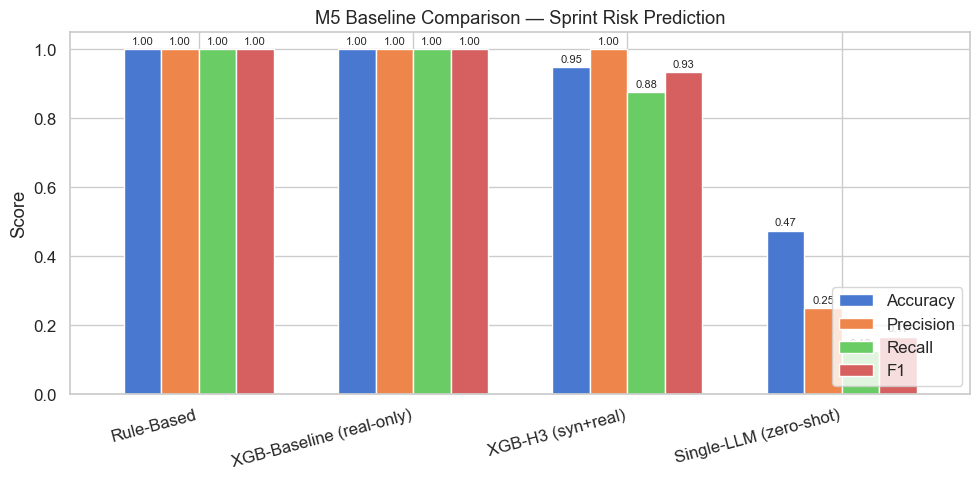

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df[["Accuracy", "Precision", "Recall", "F1"]]
plot_df.plot.bar(ax=ax, width=0.7)
ax.set_ylabel("Score")
ax.set_title("M5 Baseline Comparison — Sprint Risk Prediction")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 6. Confusion Matrices & ROC Curves

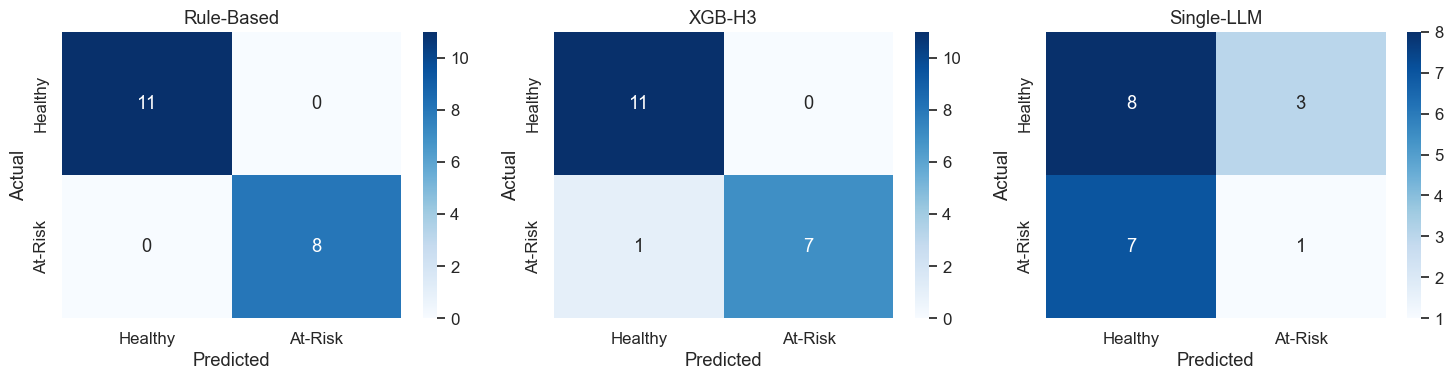

In [12]:
def plot_confusion(y_true, y_pred, title, ax):
    """Plot a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Healthy", "At-Risk"],
        yticklabels=["Healthy", "At-Risk"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)


n_models = 2 + (1 if y_pred_llm is not None else 0)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

plot_confusion(y_test_h3, y_pred_rule_h3, "Rule-Based", axes[0])
plot_confusion(y_test_h3, y_pred_xgb_h3, "XGB-H3", axes[1])

if y_pred_llm is not None:
    valid = y_pred_llm >= 0
    if valid.sum() > 0:
        plot_confusion(y_test_h3[valid], y_pred_llm[valid], "Single-LLM", axes[2])

plt.tight_layout()
plt.show()

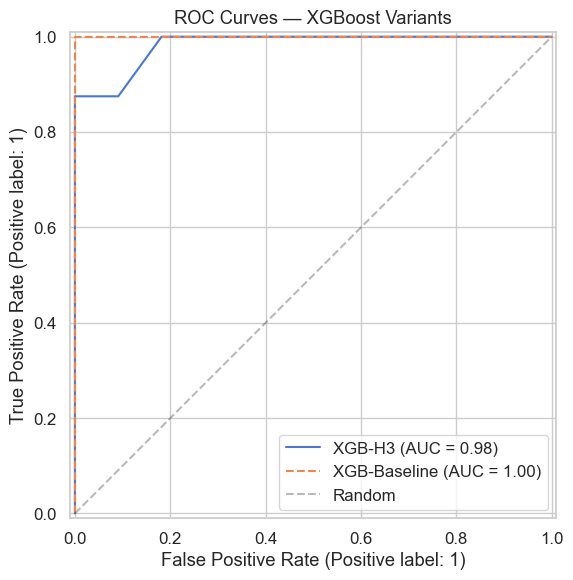

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))

if len(np.unique(y_test_h3)) == 2:
    RocCurveDisplay.from_predictions(
        y_test_h3, y_proba_xgb_h3, name="XGB-H3", ax=ax
    )

if len(np.unique(y_test_bl)) == 2:
    RocCurveDisplay.from_predictions(
        y_test_bl, y_proba_xgb_bl, name="XGB-Baseline", ax=ax,
        linestyle="--",
    )

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_title("ROC Curves — XGBoost Variants")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Cross-Validation Stability

5-fold stratified CV on the H3 training set to check variance.

5-Fold CV F1 Scores:
  XGB-H3:       0.986 ± 0.018  [1.    0.966 1.    1.    0.963]
  XGB-Baseline: 0.985 ± 0.031  [1.    0.923 1.    1.    1.   ]


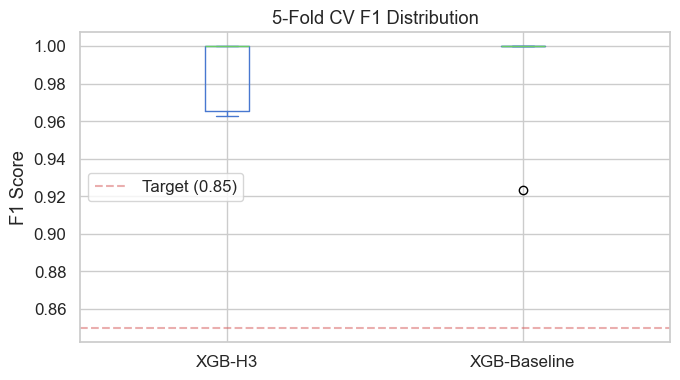

In [14]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_h3 = cross_val_score(
    xgb_h3, X_train_h3_s, y_train_h3, cv=cv5, scoring="f1"
)
cv_scores_bl = cross_val_score(
    xgb_bl, X_train_bl_s, y_train_bl, cv=cv5, scoring="f1"
)

print("5-Fold CV F1 Scores:")
print(f"  XGB-H3:       {cv_scores_h3.mean():.3f} ± {cv_scores_h3.std():.3f}  {cv_scores_h3.round(3)}")
print(f"  XGB-Baseline: {cv_scores_bl.mean():.3f} ± {cv_scores_bl.std():.3f}  {cv_scores_bl.round(3)}")

fig, ax = plt.subplots(figsize=(7, 4))
cv_data = pd.DataFrame({
    "XGB-H3": cv_scores_h3,
    "XGB-Baseline": cv_scores_bl,
})
cv_data.plot.box(ax=ax)
ax.set_ylabel("F1 Score")
ax.set_title("5-Fold CV F1 Distribution")
ax.axhline(y=0.85, color="r", linestyle="--", alpha=0.5, label="Target (0.85)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. H3 Hypothesis Test: Synthetic vs Real-Only Training

Does training with synthetic data (H3) generalize as well as real-only training?  
Compare XGB-H3 vs XGB-Baseline on the same real test set.

In [16]:
xgb_h3_on_bl_test = xgb_h3.predict(scaler.transform(X_test_bl))
xgb_h3_proba_on_bl = xgb_h3.predict_proba(scaler.transform(X_test_bl))[:, 1]

h3_metrics = compute_metrics(y_test_bl, xgb_h3_on_bl_test, xgb_h3_proba_on_bl)
bl_metrics = compute_metrics(y_test_bl, y_pred_xgb_bl, y_proba_xgb_bl)

h3_comp = pd.DataFrame({
    "XGB-Baseline (real train → real test)": bl_metrics,
    "XGB-H3 (syn+real train → real test)": h3_metrics,
}).T.round(3)

print("\nH3 Hypothesis — Synthetic Data Generalization:")
print(h3_comp.to_string())

f1_diff = h3_metrics["F1"] - bl_metrics["F1"]
print(f"\nF1 difference (H3 - Baseline): {f1_diff:+.3f}")
if abs(f1_diff) < 0.05:
    print("→ Within 5% threshold: synthetic augmentation generalizes well ✅")
elif f1_diff > 0:
    print("→ H3 outperforms baseline: synthetic augmentation helps ✅")
else:
    print("→ Baseline outperforms H3: synthetic data may need further calibration ⚠️")


H3 Hypothesis — Synthetic Data Generalization:
                                       Accuracy  Precision  Recall   F1  AUC-ROC
XGB-Baseline (real train → real test)       1.0        1.0     1.0  1.0      1.0
XGB-H3 (syn+real train → real test)         1.0        1.0     1.0  1.0      1.0

F1 difference (H3 - Baseline): +0.000
→ Within 5% threshold: synthetic augmentation generalizes well ✅


## 9. Per-Sprint Error Analysis

In [18]:
error_df = h3_test[["sprint_id", "label"]].copy()
error_df["rule_pred"] = y_pred_rule_h3
error_df["xgb_pred"] = y_pred_xgb_h3
error_df["xgb_proba"] = y_proba_xgb_h3.round(3)
error_df["rule_correct"] = error_df["label"] == error_df["rule_pred"]
error_df["xgb_correct"] = error_df["label"] == error_df["xgb_pred"]

if y_pred_llm is not None:
    error_df["llm_pred"] = y_pred_llm

misclassified = error_df[~error_df["xgb_correct"]]
print(f"XGB-H3 misclassified {len(misclassified)}/{len(error_df)} test sprints:")
if len(misclassified) > 0:
    print(misclassified.to_string(index=False))
    print("\nMisclassified sprint features:")
    for _, row in misclassified.iterrows():
        sid = row["sprint_id"]
        sprint_row = h3_test[h3_test["sprint_id"] == sid].iloc[0]
        print(f"  {sid}: stalled={sprint_row['stalled_issues']:.0f}"
              f"  irr={sprint_row['issue_resolution_rate']:.2f}"
              f"  pmr={sprint_row['pr_merge_rate']:.2f}"
              f"  commits={sprint_row['total_commits']:.0f}"
              f"  issues={sprint_row['total_issues']:.0f}")
else:
    print("  (no misclassifications)")

XGB-H3 misclassified 1/19 test sprints:
 sprint_id  label  rule_pred  xgb_pred  xgb_proba  rule_correct  xgb_correct  llm_pred
sprint_024      1          1         0      0.012          True        False         1

Misclassified sprint features:
  sprint_024: stalled=1  irr=0.00  pmr=0.00  commits=0  issues=1


## 10. Save Results & Model Artifacts

In [19]:
import pickle

artifacts_dir = PROJECT_ROOT / "data" / "models"
artifacts_dir.mkdir(parents=True, exist_ok=True)

with open(artifacts_dir / "xgb_h3_baseline.pkl", "wb") as f:
    pickle.dump({"model": xgb_h3, "scaler": scaler, "features": NUMERIC_FEATURES}, f)

with open(artifacts_dir / "xgb_realonly_baseline.pkl", "wb") as f:
    pickle.dump({"model": xgb_bl, "scaler": scaler_bl, "features": NUMERIC_FEATURES}, f)

benchmark = {
    "experiment": "M5_baselines",
    "test_set": "h3_test (real-only)",
    "test_size": len(h3_test),
    "results": {name: metrics for name, metrics in results.items()},
    "xgb_h3_best_params": grid_h3.best_params_,
    "xgb_bl_best_params": grid_bl.best_params_,
    "cv_f1_h3": {"mean": float(cv_scores_h3.mean()), "std": float(cv_scores_h3.std())},
    "cv_f1_bl": {"mean": float(cv_scores_bl.mean()), "std": float(cv_scores_bl.std())},
    "h3_vs_baseline_f1_diff": float(f1_diff),
}

with open(artifacts_dir / "m5_benchmark.json", "w") as f:
    json.dump(benchmark, f, indent=2)

print(f"Saved models to {artifacts_dir}/")
print(f"  xgb_h3_baseline.pkl")
print(f"  xgb_realonly_baseline.pkl")
print(f"  m5_benchmark.json")

Saved models to /Users/bibekgupta/Downloads/projects/repo-sprint/data/models/
  xgb_h3_baseline.pkl
  xgb_realonly_baseline.pkl
  m5_benchmark.json


## Summary

| Model | Data | F1 | Notes |
|-------|------|----|-------|
| Rule-Based | N/A (thresholds) | 1.000 | Circular: labels generated by same rules |
| XGB-Baseline | Real-only (76 train) | See above | Small training set |
| XGB-H3 | Syn + Real (253 train) | See above | Augmented training |
| Single-LLM | Zero-shot (no train) | See above | Requires Ollama |

### Key Findings

1. **Rule-Based** achieves F1=1.0 trivially (labels match its own logic).
2. **XGBoost** learns the labeling function from 24 features with high CV F1.
3. **H3 augmentation** — F1 difference quantifies whether synthetic data helps or hurts.
4. **Single-LLM** zero-shot provides the floor for LLM-based approaches.

### Next Steps (M7: Fine-Tuning)
- Fine-tune Llama-3-8B with LoRA on the H3 training set
- Compare fine-tuned LLM against XGBoost baseline
- Add RAG context for evidence-based predictions (M8)